# Attention in LLMs

In this notebook, we will discuss the attention mechanism in Large Language Models (LLMs) - one of the algorithmic breakthroughs that makes LLMs more accurate.

**Learning Objectives**

1. Describe the self-attention mechanism for transformers
2. Explain how attention scores and weights are computed
3. Implement self-attention and multi-head attention in PyTorch

**Import modules**

Begin by importing the modules to be used in this notebook

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
from torch import nn
from IPython.display import Image as IPI

In [2]:
from torch.utils.data import Dataset, DataLoader, TensorDataset
from transformers import GPT2Tokenizer, GPT2Model, GPT2LMHeadModel
import torch

In [3]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Using device:", device)

Using device: mps


## Self-Attention

Despite the assertion from GPT-2 in the previous notebook that the T in GPT stands for "Truly Great Power", this isn't the case. The T stands for Transformer, and a key part of the Transformer architecture is the self-attention mechanism. We'll take a look at that here.

First, it's helpful to have a little motivation on where this mechanism was used and why it was implemented. Using our embedded vector, we could imagine trying to make a neural network model for predictions that worked with fully connected layers in a feed-forward (FF) structure, similar to what is shown in the following diagram:

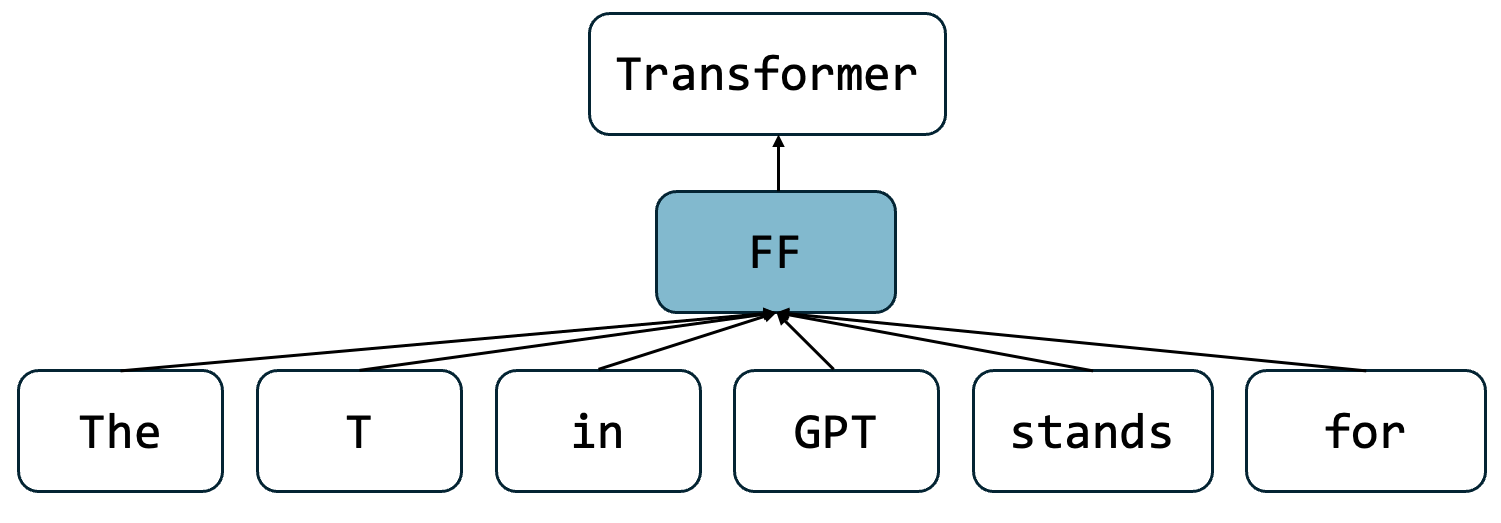

In [4]:
display(IPI(filename=os.path.join('..','images', 'GPT_FF_Schematic.png'), width=500))

Here, the FF block is a set of linear layers i.e. a multilayer perceptron. One problem with this approach is that there is no memory of previous inputs.

There were many efforts to improve upon this architecture so that relationships across tokens could be examined in different passes through the model. After many iteratation on this architecture and, in a now famous paper title "Attention is all you need" (available [HERE](https://arxiv.org/pdf/1706.03762)), it was shown that an "attention" mechanism was instrumental in improving text prediction. Since the attention mechanism is at the heart of LLMs these days, let's take a look at how it works.

### A Simple Attention Example

To consider a simple example of attention, consider the context vectors we computed in the previous notebook for each of our input tokens. We constructed this by making an embedding matrix

In [5]:
torch.manual_seed(17)
vocab_length = 6
embedding_dim = 3
embedding_matrix = nn.Embedding(vocab_length, embedding_dim)
print(embedding_matrix.weight)

Parameter containing:
tensor([[-1.0462,  1.2305, -1.1597],
        [ 0.6124,  0.3518,  0.1863],
        [ 0.9567,  0.0895,  0.0068],
        [-1.7377, -0.6994,  1.1373],
        [ 0.2750, -0.4114,  0.1158],
        [-0.2154,  0.6582,  0.2169]], requires_grad=True)


Then, we applied the embedding matrix to give a context vector

In [6]:
# generate a substring
substring = 'The T in GPT stands for'

# create the dictionary
vocab = {'for':0, 'in':1, 'stands':2,
         'GPT':3, 'T': 4, 'The':5}

# tokenize
tokens = []
for word in substring.split():
    tokens.append(vocab[word])
print('Tokens:\n',tokens)

# embed
embedded_inputs = embedding_matrix.weight[torch.tensor(tokens)]
print('Embedded Inputs:\n',embedded_inputs)

Tokens:
 [5, 4, 1, 3, 2, 0]
Embedded Inputs:
 tensor([[-0.2154,  0.6582,  0.2169],
        [ 0.2750, -0.4114,  0.1158],
        [ 0.6124,  0.3518,  0.1863],
        [-1.7377, -0.6994,  1.1373],
        [ 0.9567,  0.0895,  0.0068],
        [-1.0462,  1.2305, -1.1597]], grad_fn=<IndexBackward0>)


Next, we are interested in how each of these embedding vectors interrelate. Here, we compute **attention scores** as the dot product between a given embedded vector and the others. For example, consider the embedded vector corresponding to the second token (for T). We can compute the attention scores for this vector relative to the other vectors as follows:

In [7]:
query = embedded_inputs[1]

for i in range(6):
    print(f'Attention score a_{i}: {torch.dot(embedded_inputs[i], query):.4f}')

Attention score a_0: -0.3049
Attention score a_1: 0.2583
Attention score a_2: 0.0452
Attention score a_3: -0.0584
Attention score a_4: 0.2270
Attention score a_5: -0.9282


The rationale behind this approach is that the dot product tells us how well two vectors are aligned. I.e. Recall that, for two vectors $a$ and $b$, the angle $\theta$ between them is related to the dot product as:

$$
\cos(\theta) = \frac{a\cdot b}{|a||b|}
$$

In other words, the smaller $\theta$ is to 0 (i.e. how "aligned" the vectors are), the larger the dot product.

This can be computed more concisely using matrix multiplication. If we call our collection of embedded vectors $X$, then the attention scores are computed as $A=XX^T$ i.e.

In [8]:
attention_scores = embedded_inputs @ embedded_inputs.T
print(attention_scores[1])

tensor([-0.3049,  0.2583,  0.0452, -0.0584,  0.2270, -0.9282],
       grad_fn=<SelectBackward0>)


Once we have our attention scores, we normalize them to compute attention weights:

In [9]:
attention_weights = torch.softmax(attention_scores, dim=-1)
print(attention_weights[1])

tensor([0.1300, 0.2283, 0.1845, 0.1663, 0.2213, 0.0697],
       grad_fn=<SelectBackward0>)


Finally, once we have these attention weights, we use them to combine each of the embedded inputs into a set of *context vectors* that represents not only the inputs, but also how they are related. Again this can be done with matrix multiplication as $AX$ i.e.

In [10]:
context_vectors = attention_weights @ embedded_inputs
print(context_vectors[1])
print(context_vectors.shape)

tensor([-0.0025,  0.0458,  0.1988], grad_fn=<SelectBackward0>)
torch.Size([6, 3])


As we can see, the context vector has the same length as the corresponding embedded vector, but it now has different values.

### Attention with Trainable Weights
In the above example, we computed attention weights using the dot product of our vector with others. However, these weights are not learnable parameters. To give the model a mechanism to learn patterns for attention, the self-attention mechanism introduces three weight matrices with learnable parameters - so-called the query ($W_q$), key ($W_k$), and value ($W_v$) matrices, borrowing from jargon for dictionaries. 

For a given set of embedded vectors $X$, we compute the attention scores as

$$
A = (W_qX) (W_k X)^T
$$

Note that, just like above, this is the same thing as computing the dot products of the inputs - the only difference is now there is a weighting component introduced.

After these scores are normalized, they are used to compute the context vector along with the weights from $W_v$, i.e. $A(W_v X)$.

We can code this up with PyTorch in the following function:

In [11]:
class SelfAttention(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=False)
        self.W_key = nn.Linear(d_in, d_out, bias=False)
        self.W_value = nn.Linear(d_in, d_out, bias=False)

    def forward(self, x):
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        attention_scores = queries @ keys.T
        attention_weights = torch.softmax(attention_scores / keys.shape[-1]**0.5, dim=-1)
        context_vector = attention_weights @ values
        return(context_vector)

Let's see this attention mechanism in action:

In [12]:
attention = SelfAttention(3,3)
attention(embedded_inputs)

tensor([[-0.1323,  0.0196, -0.1129],
        [-0.1178,  0.0299, -0.0982],
        [-0.1332, -0.0061, -0.0837],
        [-0.1373,  0.0621, -0.1535],
        [-0.1250, -0.0033, -0.0748],
        [-0.0870,  0.1149, -0.1732]], grad_fn=<MmBackward0>)

We can see above that each of the embedded vectors was mapped onto a corresponding context vector. This is a small demo to showcase the processes of attention - in a real model, these weights would be trained based on patterns in the training text.

## Multi-head Attention

If one set of training in the weights is good, then surely more is better! (Right?). In the transformer architecture, the attention mechanism has several sets of  "heads" that yield independent attention scores. For example, GPT-2 has 12 sets of attention scores for computing sets of context vectors (err... heads).

The following code shows how multi-head attention can be coded up efficiently in PyTorch. There are a few additional bells and whistles here (batches, dropout layers, a mask, and a linear output layer) but the core functionality described above is intact. We will use this class in our subsequent notebook coding up GPT-2 from scratch.

In [13]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out,
                 context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out//num_heads
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        batches, num_tokens, d_in = x.shape
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        keys = keys.view(batches, num_tokens, self.num_heads, self.head_dim)
        values = values.view(batches, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(batches, num_tokens, self.num_heads, self.head_dim)

        keys = keys.transpose(1,2)
        queries = queries.transpose(1,2)
        values = values.transpose(1,2)
        
        attention_scores = queries @ keys.transpose(2,3)
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        attention_scores.masked_fill_(mask_bool, -torch.inf)

        attention_weights = torch.softmax(attention_scores / keys.shape[-1]**0.5, dim=-1)
        attention_weights = self.dropout(attention_weights)

        context_vector = (attention_weights @ values).transpose(1, 2)

        context_vector = context_vector.contiguous().view(batches, num_tokens, self.d_out)

        context_vector = self.out(context_vector)
        return(context_vector)

As before, we can test out this function as follows:

In [14]:
attention = MultiHeadAttention(3,3,
                               context_length=6, dropout=0.0, num_heads=3)
batched_embedded_inputs = embedded_inputs.unsqueeze(0)
output = attention(batched_embedded_inputs)
print(output.shape)

torch.Size([1, 6, 3])


As models have grown more sophisticated, the number of attention heads in their transformers have also grown. The following table shows the number of attention heads in publicly-released architectures:

|Model | Attention Heads|
|------|----------------|
| GPT-2 Small | 12|
| GPT-2 Medium | 16	|
| GPT-2 Large | 20	|
| GPT-2 XL | 25	|
| GPT-3 Ada | 16|
| GPT-3 Babbage | 32|
| GPT-3 Curie | 64|
| GPT-3 Davinci | 96|

**Key Takeaways**

1. Attention allows each token to “focus” on relevant parts of the input
2. Context vectors combine information across tokens
3. Multi-head attention allows the model to capture multiple types of relationships simultaneously